In [14]:
import tensorflow as tf
from matplotlib import pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, models

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np

In [15]:
import warnings

warnings.filterwarnings('ignore')

In [16]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

In [17]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [18]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

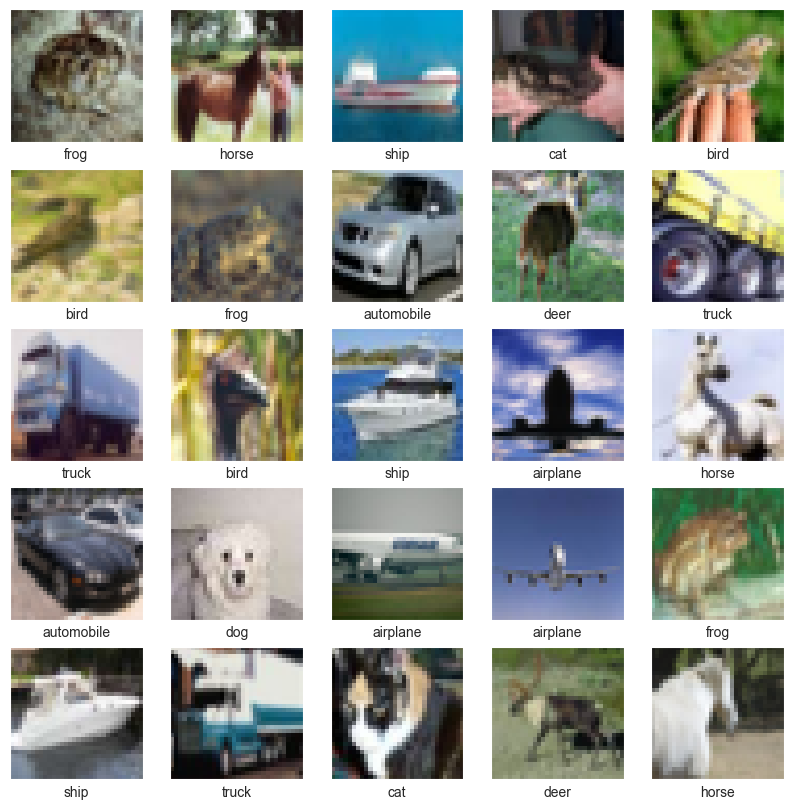

In [19]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(class_names[y_train[i][0]])
plt.show()

In [20]:
x_train, x_val, x_test = x_train / 255.0, x_val / 255.0, x_test / 255.0

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

In [21]:
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal", input_shape=(32, 32, 3)),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])

In [22]:
def run_pipeline(model: models.Sequential, n_epoch=30, patience=5):
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=patience,
        restore_best_weights=True,
        mode='max'
    )

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=0.0001,
        verbose=1
    )

    history = model.fit(
        x_train,
        y_train,
        epochs=n_epoch,
        validation_data=(x_val, y_val),
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

    actual_epochs = len(history.history['accuracy'])
    print(f"Обучение остановлено на эпохе {actual_epochs}/{n_epoch}")

    if actual_epochs < n_epoch:
        print(f"Ранняя остановка сработала после {n_epoch - actual_epochs} эпох без улучшения")


    y_pred = model.predict(x_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = y_test.flatten()

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    top3_pred = np.argsort(y_pred, axis=1)[:, -3:]
    top3_correct = np.array([y_true[i] in top3_pred[i] for i in range(len(y_true))])
    top3_accuracy = np.mean(top3_correct)
    print(f"Accuracy: {acc[-1]}, Top3 Accuracy: {top3_accuracy}")

    fig, ax1 = plt.subplots(figsize=(12, 5))

    color = 'tab:red'
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss', color=color)
    line1 = ax1.plot(epochs, loss, 'o-', color=color, label='Training Loss')[0]
    line2 = ax1.plot(epochs, val_loss, 's-', color=color, alpha=0.5, label='Test Loss')[0]
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('Accuracy', color=color)
    line3 = ax2.plot(epochs, acc, 'o-', color=color, label='Training Accuracy')[0]
    line4 = ax2.plot(epochs, val_acc, 's-', color=color, alpha=0.5, label='Test Accuracy')[0]
    ax2.tick_params(axis='y', labelcolor=color)

    lines = [line1, line2, line3, line4]
    labels = [str(line.get_label()) for line in lines]
    ax1.legend(lines, labels, loc='center right')

    plt.title('Модель')
    plt.show()


    print(classification_report(y_true, y_pred_classes, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred_classes)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    wrong_indices = np.where(y_pred_classes != y_true)[0]

    if len(wrong_indices) > 0:
        n_errors_to_show = min(12, len(wrong_indices))
        fig, axes = plt.subplots(3, 4, figsize=(15, 12))
        axes = axes.ravel()

        for i in range(n_errors_to_show):
            idx = wrong_indices[i]
            axes[i].imshow(x_test[idx])
            axes[i].set_title(f'True: {class_names[y_true[idx]]}\n'
                            f'Pred: {class_names[y_pred_classes[idx]]}\n'
                            f'Confidence: {y_pred[idx][y_pred_classes[idx]]:.2f}')
            axes[i].axis('off')

        plt.suptitle('Model Prediction Errors (True vs Predicted)', fontsize=16)
        plt.tight_layout()
        plt.show()

        print(f"Всего {len(wrong_indices)} ошибок на {len(y_test)} примеров "
              f"({100*len(wrong_indices)/len(y_test):.2f}% процент ошибок)")
    else:
        print("Ошибок нет!")

    return y_pred_classes


In [23]:
model_simple = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10),
    layers.Dense(10, activation='softmax')
])

Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.4001 - loss: 1.6575 - val_accuracy: 0.4825 - val_loss: 1.4369 - learning_rate: 0.0010
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5043 - loss: 1.3847 - val_accuracy: 0.5607 - val_loss: 1.2443 - learning_rate: 0.0010
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5439 - loss: 1.2761 - val_accuracy: 0.5974 - val_loss: 1.1572 - learning_rate: 0.0010
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5691 - loss: 1.2115 - val_accuracy: 0.6048 - val_loss: 1.1460 - learning_rate: 0.0010
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5887 - loss: 1.1611 - val_accuracy: 0.6221 - val_loss: 1.0945 - learning_rate: 0.0010
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.6026 - loss: 1.1233 - val_accuracy: 0.6258 - val_loss: 1.0687 - learning_rate: 0.0010
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.6128 -

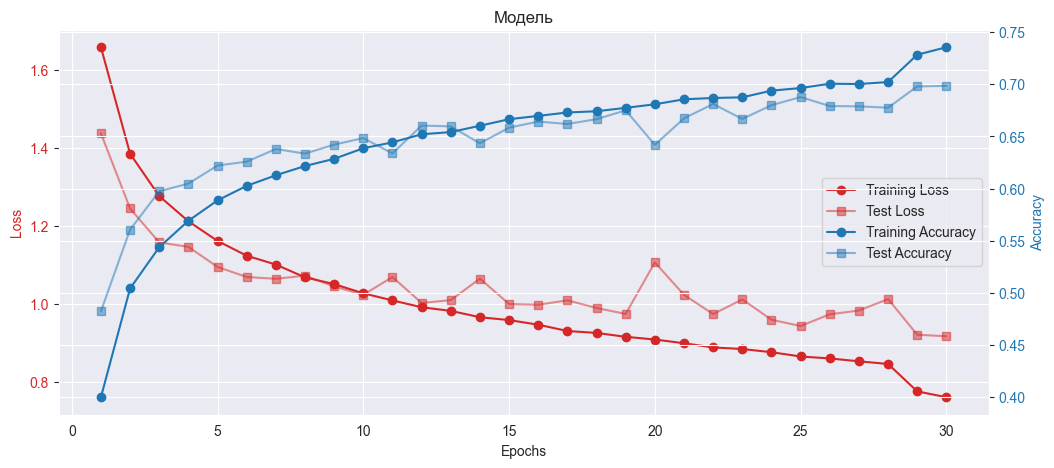

              precision    recall  f1-score   support

    airplane       0.72      0.76      0.74      1000
  automobile       0.79      0.84      0.82      1000
        bird       0.71      0.51      0.59      1000
         cat       0.62      0.41      0.49      1000
        deer       0.67      0.57      0.62      1000
         dog       0.65      0.61      0.63      1000
        frog       0.66      0.83      0.73      1000
       horse       0.65      0.80      0.72      1000
        ship       0.83      0.79      0.81      1000
       truck       0.66      0.84      0.74      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.69     10000
weighted avg       0.70      0.70      0.69     10000



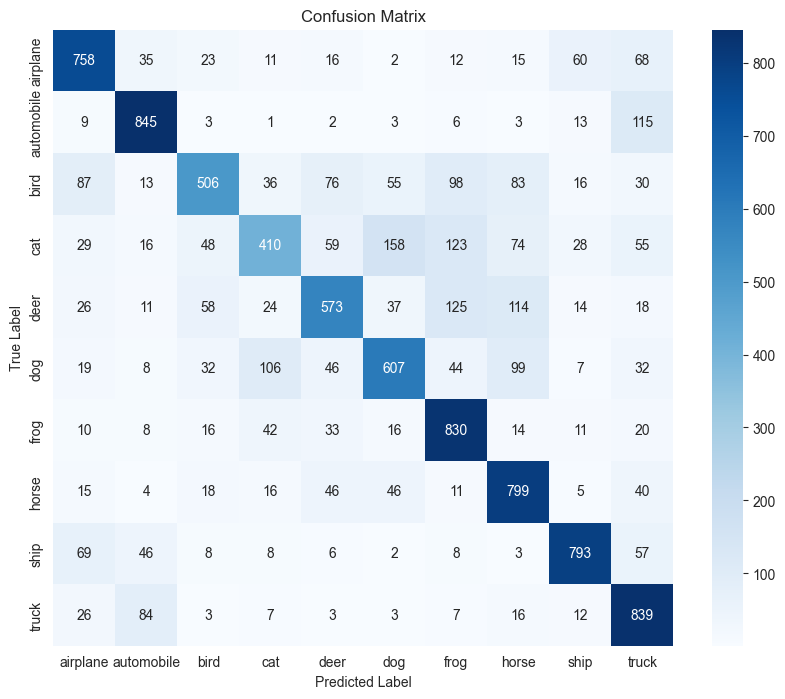

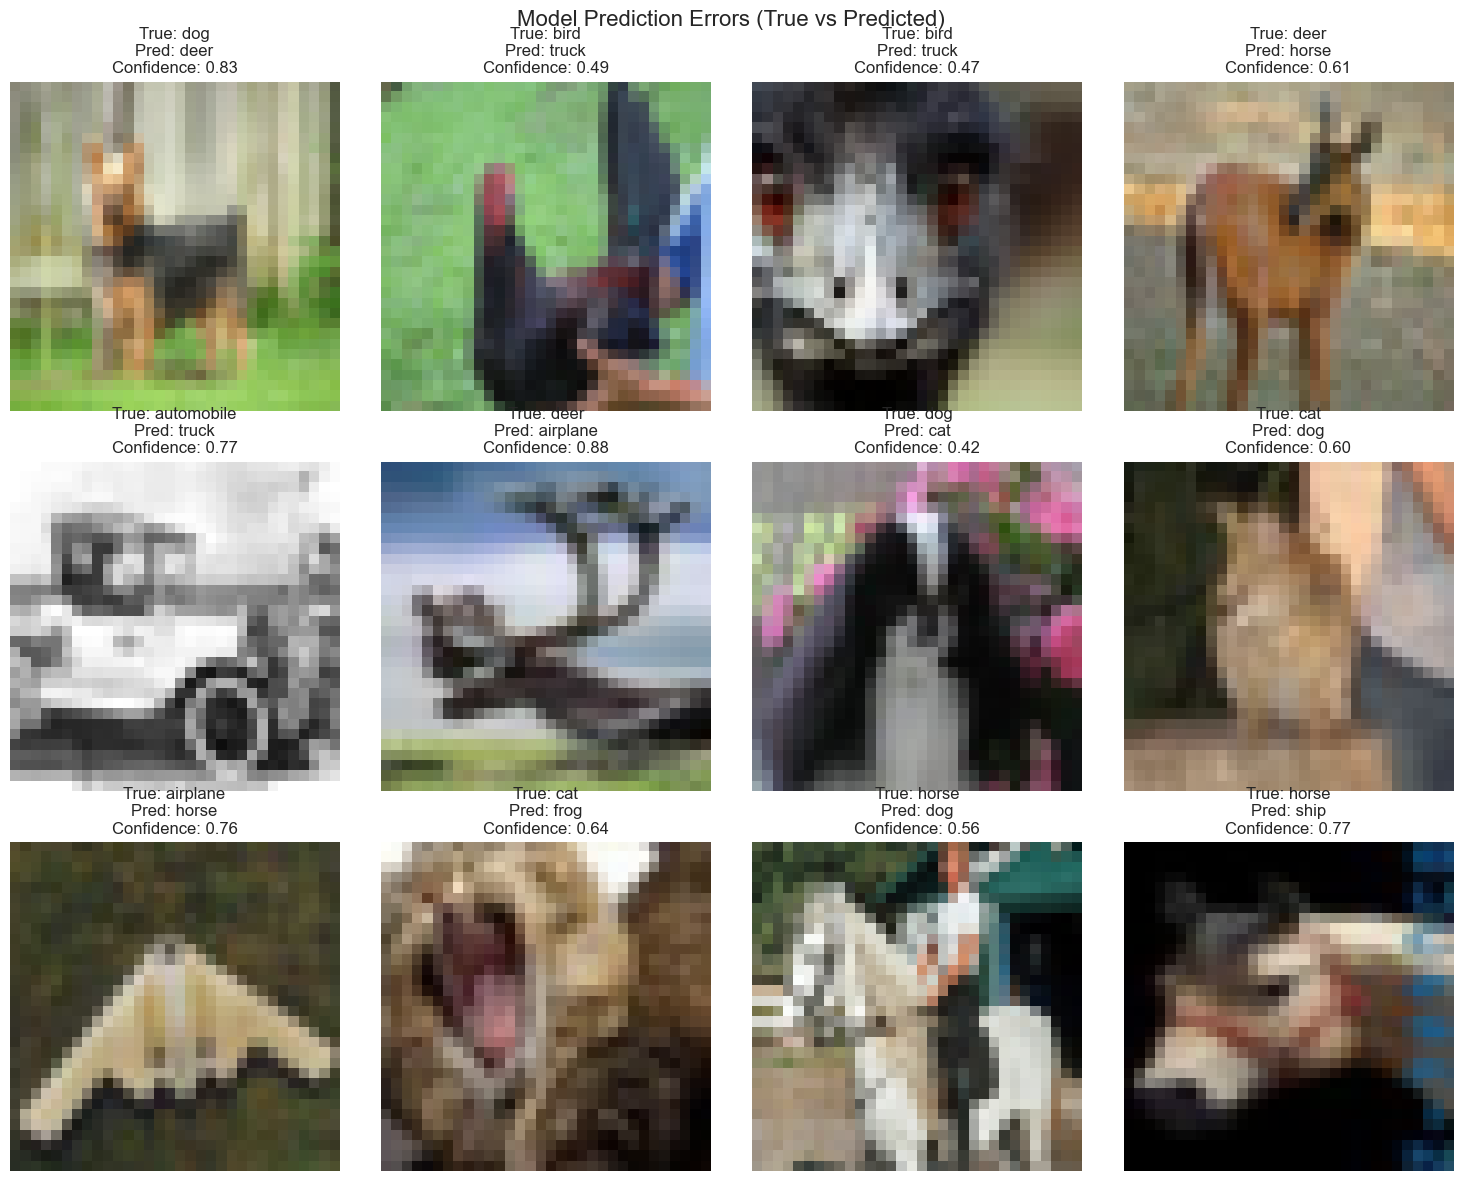

Всего 3040 ошибок на 10000 примеров (30.40% процент ошибок)


array([3, 8, 8, ..., 5, 1, 7], shape=(10000,))

In [24]:
run_pipeline(model_simple)

In [25]:
model_deep = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 49s 38ms/step - accuracy: 0.3746 - loss: 1.7781 - val_accuracy: 0.4807 - val_loss: 1.4617 - learning_rate: 0.0010
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 50s 40ms/step - accuracy: 0.4823 - loss: 1.4530 - val_accuracy: 0.5243 - val_loss: 1.4050 - learning_rate: 0.0010
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 50s 40ms/step - accuracy: 0.5382 - loss: 1.2984 - val_accuracy: 0.5980 - val_loss: 1.1318 - learning_rate: 0.0010
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 50s 40ms/step - accuracy: 0.5816 - loss: 1.1946 - val_accuracy: 0.5936 - val_loss: 1.1930 - learning_rate: 0.0010
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 52s 41ms/step - accuracy: 0.6062 - loss: 1.1228 - val_accuracy: 0.6283 - val_loss: 1.0439 - learning_rate: 0.0010
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 52s 42ms/step - accuracy: 0.6271 - loss: 1.0697 - val_accuracy: 0.6098 - val_loss: 1.1751 - learning_rate: 0.0010
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 53s 43ms/step - accura

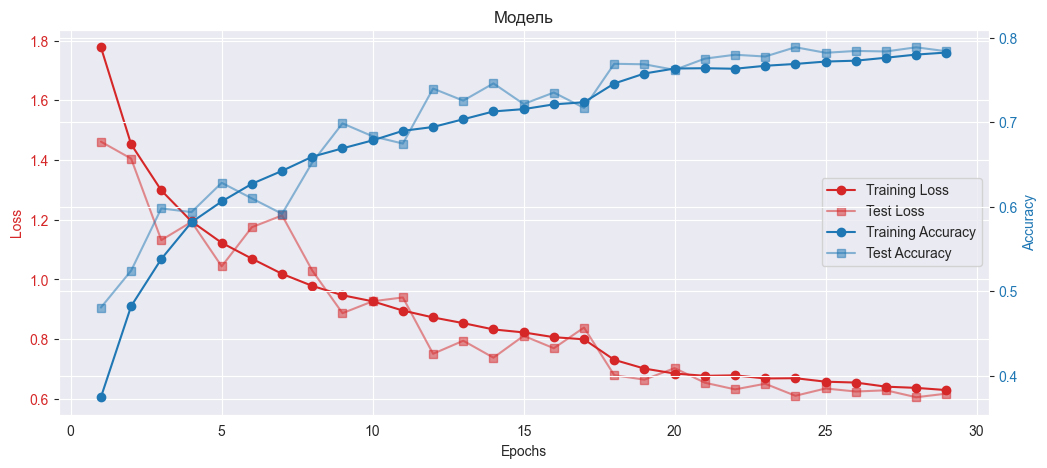

              precision    recall  f1-score   support

    airplane       0.83      0.80      0.81      1000
  automobile       0.90      0.90      0.90      1000
        bird       0.84      0.63      0.72      1000
         cat       0.72      0.58      0.64      1000
        deer       0.76      0.75      0.76      1000
         dog       0.80      0.68      0.73      1000
        frog       0.70      0.94      0.80      1000
       horse       0.80      0.86      0.83      1000
        ship       0.89      0.87      0.88      1000
       truck       0.75      0.93      0.83      1000

    accuracy                           0.79     10000
   macro avg       0.80      0.79      0.79     10000
weighted avg       0.80      0.79      0.79     10000



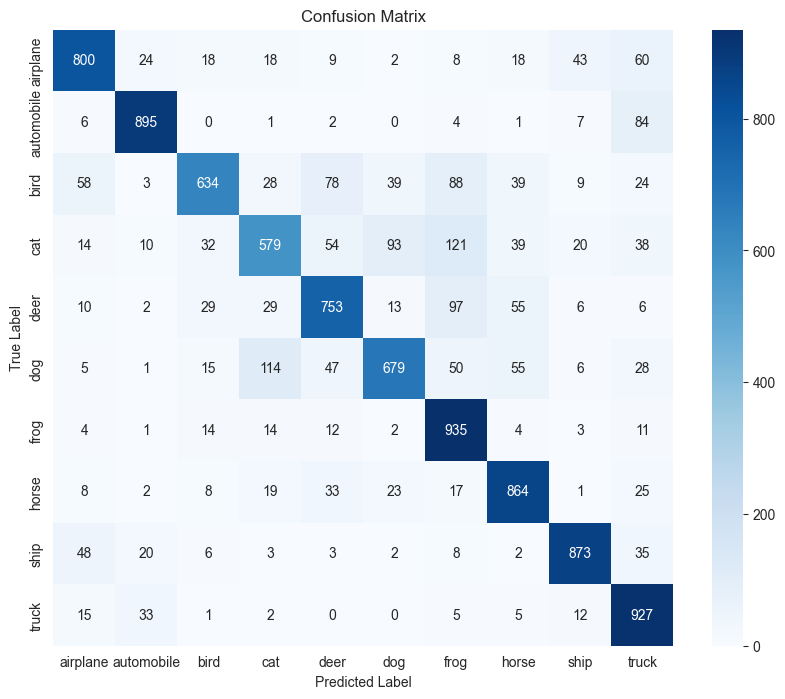

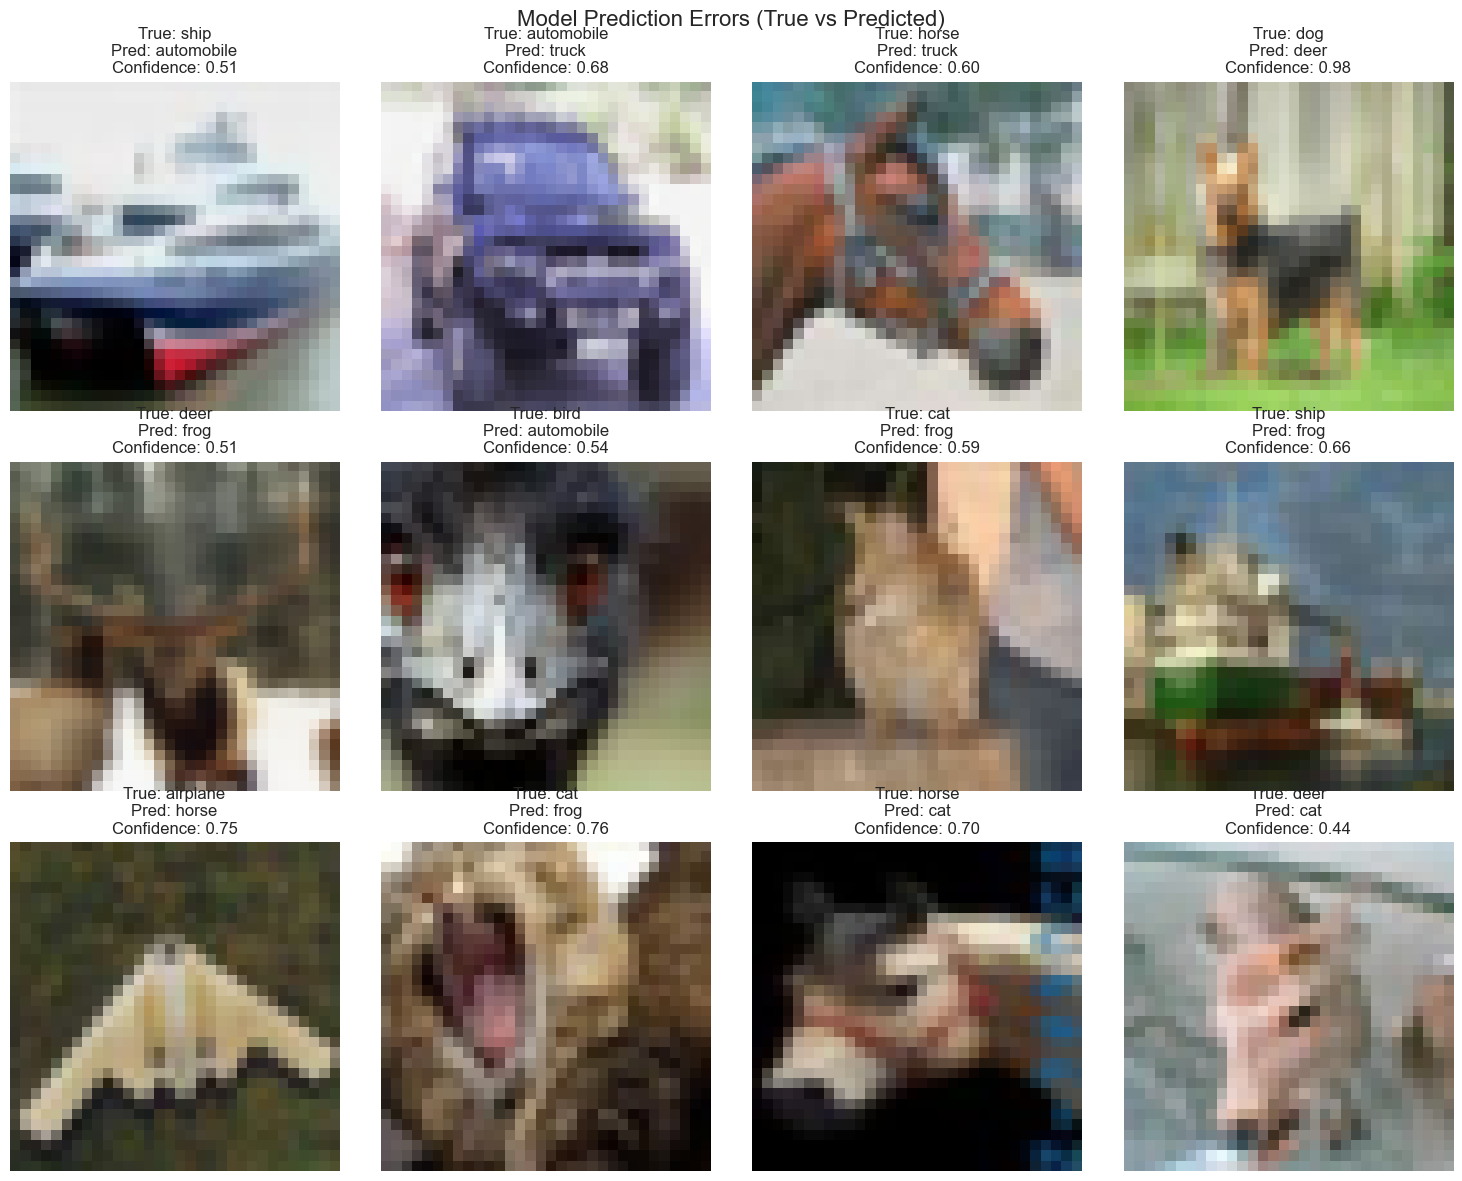

Всего 2061 ошибок на 10000 примеров (20.61% процент ошибок)


array([3, 1, 8, ..., 5, 1, 7], shape=(10000,))

In [26]:
run_pipeline(model_deep)